In [ ]:
# ROBUST OPTIMIZATION PROJECT

In [ ]:
# Created on 11.03.2024 by Davide Carecci
# 29.04.2024 expired licence for mosek solver!

In [1]:
import sys
print(sys.path)

['C:\\Users\\lenovo\\OneDrive - Politecnico di Milano\\Work_cloud\\DOTTORATO\\Robust Optimization\\Project', 'C:\\ModelonImpact-1.8.1\\oct-dist\\install\\Python', 'C:\\Users\\lenovo\\OneDrive - Politecnico di Milano\\Work_cloud\\DOTTORATO\\Robust Optimization\\Project', 'C:\\ModelonImpact-1.8.1\\oct-dist\\Python37\\python37.zip', 'C:\\ModelonImpact-1.8.1\\oct-dist\\Python37\\DLLs', 'C:\\ModelonImpact-1.8.1\\oct-dist\\Python37\\lib', 'C:\\ModelonImpact-1.8.1\\oct-dist\\Python37', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv', '', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv\\lib\\site-packages', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv\\lib\\site-packages\\win32', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv\\lib\\site-packages\\win32\\lib', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv\\lib\\site-packages\\Pythonwin', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv\\lib\\site-packages\\IPython\\extensions', 'C:\\Users\\lenovo\\.ipython']


In [113]:
# Add a new path to sys.path
new_path = 'C:\\ModelonImpact-1.8.1\\oct-dist\\Python37\\Lib\\site-packages'
sys.path.append(new_path)

In [5]:
#import rsome as rso
import numpy as np
import pandas as pd
#from rsome import ro
#from rsome import msk_solver as my_solver  #Import Mosek solver interface
import matplotlib.pyplot as plt
#from rsome import grb_solver as my_solver  #Import Gurobi solver interface

In [6]:
import numpy as np
from scipy.integrate import odeint

# Define the differential equations
def model(state, t, k1, k2):
    x, y, z = state
    dxdt = -k1 * x
    dydt = -k2 * y
    dzdt = k1 * x + k2 * y
    return [dxdt, dydt, dzdt]

def evaluate_model(x0,y0,k1,k2):

    # Initial conditions
    x0 = x0
    y0 = y0
    z0 = 0.0

    # Time points to solve the equations
    t = np.linspace(0, 50, 50)

    # Rate constants
    k1 = k1
    k2 = k2

    # Solve the differential equations
    state = odeint(model, [x0, y0, z0], t, args=(k1, k2))
    x_response = state[:, 0]
    y_response = state[:, 1]
    z_response = state[:, 2]
    
    return t,z_response

In [13]:
# LOAD DATA
# Few data are available to estimate distribution...hypothesis? Theorem to be conservative
# Load data if they already exist for further manipulation
def read_excel_file(file_path):
    # Read the Excel file and return a dictionary of DataFrames for each sheet
    xls = pd.ExcelFile(file_path)
    sheet_dict = {sheet_name: pd.read_excel(xls, sheet_name, skiprows=[1]) for sheet_name in xls.sheet_names}
    return sheet_dict

# Replace 'your_file.xlsx' with the actual file path
file_path = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Robust Optimization/Project/Project_database.xlsx'

# Step 1: Read Excel file and create a dictionary of DataFrames for each sheet
data = read_excel_file(file_path)

In [14]:
# Declare constants and parameters
n = 10 #number of items (co-substrates)
m = 20 #number of suppliers

Vr = 2*1350+3179 #m3 
N = 365 #purchase horizon (days)
p_ch4 = 110 #fixed biomethane price
p_ch4 = 110 *0.01035 #Conversion MWh/Nm3CH4

bnds = np.array([[0, 120], #VS
        [0.2, 4], #TKN
        [20, 40], #C/N
        [0, 4], #TAN
        [5, 15], #TAC
        [0, 10], #LI
        [0, 10], #TVFA
        [20,40] #HRT
       ])

In [15]:
k_hydr = data['Item characteristics'].values[:,13].astype('float64')
k_hyds = data['Item characteristics'].values[:,14].astype('float64')
BMPinf_r = data['Item characteristics'].values[:,15].astype('float64')
BMPinf_s = data['Item characteristics'].values[:,16].astype('float64')
itemtype = data['Item characteristics'].values[:,-1]

In [16]:
# SAMPLE BMP CURVE 
# This has to be done for each realization of BMPinf when addressing the robust counterpart
# Assume BMPinf_r and BMPinf_s has the same distribution of BMPinf
bmp_curve = []
for k1,k2,x0,y0 in zip(k_hydr,k_hyds,BMPinf_r,BMPinf_s):
    t,z_response = evaluate_model(x0,y0,k1,k2)
    bmp_curve.append(z_response)

    # Calculate dz/dt using numerical differentiation
    dt = t[1] - t[0]
    dzdt_response = np.gradient(z_response, dt)

    # Plot the time response
    #fig, ax = plt.subplots(figsize=(12, 6))
    ##ax.plot(t, x_response, label='x(t)')
    ##ax.plot(t, y_response, label='y(t)')
    #ax.plot(t, z_response, label='z(t)', marker= 'o')
    #ax.plot(t, dzdt_response, label='dz/dt')
    #plt.xlabel('Time')
    #plt.ylabel('Concentration / Rate')
    #plt.title('Time Response of State Variables and their Rates')
    #plt.legend()
    #plt.grid(True)
    #plt.show()
bmp_curve = np.array(bmp_curve, dtype=np.float64)
#print(bmp_curve)

0.6427144300732189

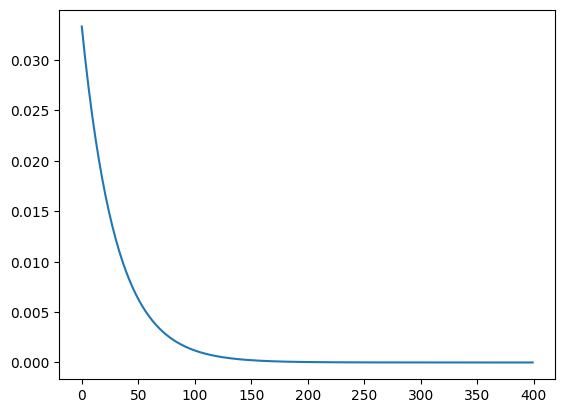

In [17]:
res_curve = []
HRT=30
for t in range(400):
    residence_time = 1/HRT*np.e**(-t/HRT)
    res_curve.append(residence_time)
plt.plot(res_curve)
sum(res_curve[:30])

In [26]:
print(bmp_curve[-1][29])
bmp_cstr = []
for i in range(50):
    #print(i)
    #bmp_time = res_curve[i]*dzdt_response[i]
    bmp_time = res_curve[i]*bmp_curve[-1][i]
    #bmp_time = res_curve[i]*(30-i)*dzdt_response[i]
    #print(bmp_time)
    bmp_cstr.append(bmp_time)
print(sum(bmp_cstr))
#sum(dzdt_response[:28])

331.8822721563368
244.82188278121205


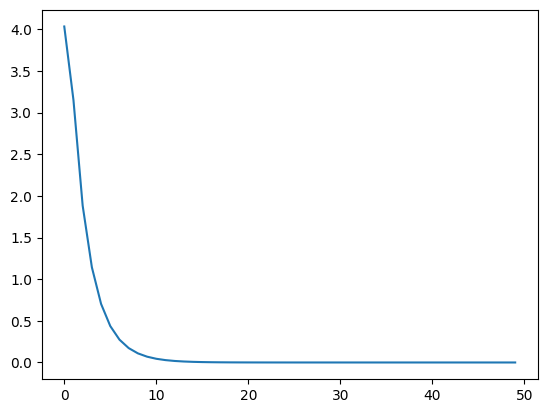

In [24]:
plt.plot(bmp_cstr)

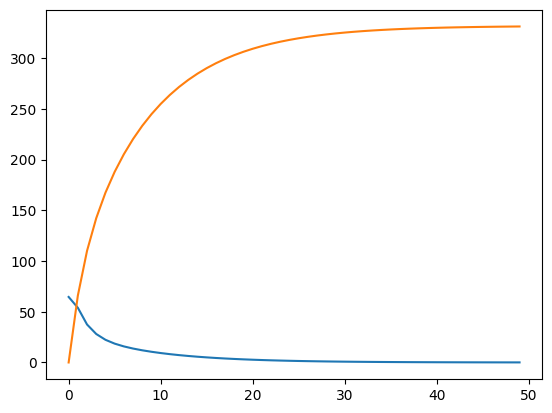

In [179]:
plt.plot(dzdt_response)
plt.plot(bmp_curve[-1])

In [9]:
# Re-declaration of loaded data
# To load also Max/Mean and Min/Mean ratios (to generate realizations), other rows are need to be loaded i.e. [3:4]
A = data['Availability'].values[5:25,1:11].astype('float64')

# To load also Max/Mean and Min/Mean ratios (to generate realizations), other columns are need to be loaded i.e. [21:28]
k = np.concatenate(([data['Item characteristics'].values[:,3]], data['Item characteristics'].values[:,6:12].T), axis=0).T
k = k.astype('float64')

VS = data['Item characteristics']['VS'].values.astype('float64')
BMPinf = data['Item characteristics']['BMPinf'].values.astype('float64') #We must sample this from the curve fixing HRT
Cp = data['Purchase prices'].values[5:25,1:11].astype('float64')

# Compute the matrix of transportation costs
Fixed_tariff = data['Item characteristics']['Fixed_tariff'].values.astype('float64')
d = data['Ct']['d'].values.astype('float64')
d = d.reshape(-1, 1)
matrix = np.tile(Fixed_tariff, (m, 1))
Ct = (matrix + d)/20

In [ ]:
# Just for checking purposes
x = np.random.rand(10,20)
f_obj = p_ch4*(VS*BMP/1000)@x.sum(axis=1)
f_obj2 = (Cp.T*x).sum()
f_obj3 = (Ct.T*x).sum()

In [ ]:
# Just for checking purposes
#print(k[:,1])
for i in range(np.size(k,1)):
    ciao = k[:,i]@(x.sum(axis=1))
    print(ciao)

In [116]:
#Solve the nominal problem

# Find indices correspondent to a certain cluster to apply 'regulating authority constraints'
table1A = np.isin(itemtype,['S','B'])
table1B = np.isin(itemtype,['P'])
slurries = np.isin(itemtype,['S'])
secondharvest = np.isin(itemtype,['P2'])
Nminus1 = 1/N

#Create model
model=ro.Model('Biomethane supply-chain')

#Define variables
x = model.dvar((n,m))          #

#List the objective and constraints
model.max(Nminus1*(p_ch4*(VS*BMPinf/1000)@x.sum(axis=1)-(Cp.T*x).sum()-(Ct.T*x).sum()))
#model.st(x <= A)       # Stock constraint
model.st(x <= A.T)       # Availability constraint
for i in range(np.size(k,1)):
    model.st(k[:,i]@(x.sum(axis=1)) <= bnds[i][1]*x.sum()) # Technical constraint (max)
    model.st(k[:,i]@(x.sum(axis=1)) >= bnds[i][0]*x.sum()) # Technical constraint (min)
model.st(Vr*N <= bnds[7][1]*x.sum()) # HRT constraint (max)
model.st(Vr*N >= bnds[7][0]*x.sum()) # HRT constraint (min)
model.st(x >= 0)

# Add constraints from regulating autorithy
model.st(x[table1A].sum() >= 0.7*x.sum())
model.st(x[table1B].sum() <= 0.3*x.sum())
model.st(x[secondharvest].sum() <= 0.2*x.sum())
model.st(x[slurries].sum() >= 0.4*x.sum())

#Add constraint to consume substrate of 'myplant'
model.st(x.T[-1] == A[-1])

#Solve the model
model.solve(my_solver)
opt_obj = model.get()  #
opt_x = x.get()

print('The net revenue for the purchase horizon of interest is', round(opt_obj,2), 
      'euro/day and the optimal fluxes of items to be purchased are', np.round(opt_x, decimals=2))

Being solved by Mosek...


Error: rescode.err_license_expired(1001): The license has expired.


In [ ]:
# Just for checking purposes
x = opt_x
HRT = Vr*N/x.sum()
print(f'HRT is {HRT}')
f_obj = p_ch4*(VS*BMPinf/1000)@x.sum(axis=1)
f_obj2 = (Cp.T*x).sum()
f_obj3 = (Ct.T*x).sum()
print(f_obj)
print(f_obj2)
print(f_obj3)
print(f_obj-f_obj2-f_obj3)


#diet
for i,name in zip(range(len(x)),data['Item characteristics'].values[:,0]):
    itempercentage = x[i].sum()/x.sum()*100
    print(f'{name} is {round(itempercentage,2)}% of the influent diet')
    

# Check which constraint is active 

table1A = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S','B'])]).sum()
table1B = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P'])]).sum()
slurries = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S'])]).sum()
secondharvest = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P2'])]).sum()
ciao = [table1A*100/x.sum() - 70, 30 - table1B*100/x.sum(), slurries*100/x.sum() - 40, 20 - secondharvest*100/x.sum()]
for i in range(len(ciao)):
    active = [ciao[i] if ciao[i]<0 else 0]
    print(f'Autorithy constraint {i} not respected by {round(active[0],2)}')

#
for i in range(np.size(k,1)):
    deltamax = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][1] # Technical constraint (max)
    deltamin = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][0] # Technical constraint (min)
    print(f'Technical constriant {i} has margin to UB equal to {round(deltamax,2)}')
    print(f'Technical constriant {i} has margin to LB equal to {round(deltamin,2)}')
deltaHRTmax = Vr*N/x.sum() - bnds[7][1] # HRT constraint (max)
print(f'HRT constriant has margin to UB equal to {round(deltaHRTmax,2)}')
deltaHRTmin = Vr*N/x.sum() - bnds[7][0] # HRT constraint (min)
print(f'HRT constriant has margin to LB equal to {round(deltaHRTmin,2)}')

In [13]:
#Solve the nominal problem + HRT optimization

# Find indices correspondent to a certain cluster to apply 'regulating authority constraints'
table1A = np.isin(itemtype,['S','B'])
table1B = np.isin(itemtype,['P'])
slurries = np.isin(itemtype,['S'])
secondharvest = np.isin(itemtype,['P2'])

#Extract value from 'bmp_curve' at the given HRT
HRT=50
HRTminus1 = 1/HRT
Nminus1 = 1/N
BMP = []
for i in range(len(data['Item characteristics'].values[:,0])):
    BMPsubstrate = bmp_curve[i][HRT-1]
    BMP.append(BMPsubstrate)
BMP = np.array(BMP)

#Create model
model=ro.Model('Biomethane supply-chain real')

#Define variables
x = model.dvar((n,m))          #

#List the objective and constraints
model.max(Nminus1*(p_ch4*(VS*BMP/1000)@x.sum(axis=1)-(Cp.T*x).sum()-(Ct.T*x).sum())) #How shall I reformulate the objective function?
#model.st(x <= A)       # Stock constraint
model.st(x <= A.T)       # Availability constraint
for i in range(np.size(k,1)):
    model.st(k[:,i]@(x.sum(axis=1)) <= bnds[i][1]*x.sum()) # Technical constraint (max)
    model.st(k[:,i]@(x.sum(axis=1)) >= bnds[i][0]*x.sum()) # Technical constraint (min)
model.st(Vr*N == HRT*x.sum()) # HRT hard constraint 
model.st(x >= 0)

#Add constraint to consume substrate of 'myplant'
model.st(x.T[-1] == A[-1])

#Add constraint to limit output residual BMP in digestate (authority limit)
#model.st((BMPinf-BMP)@(x.sum(axis=1)) <= (0.15*BMPinf)@(x.sum(axis=1)))

# Add constraints from regulating autorithy
model.st(x[table1A].sum() >= 0.7*x.sum())
model.st(x[table1B].sum() <= 0.3*x.sum())
model.st(x[secondharvest].sum() <= 0.2*x.sum())
model.st(x[slurries].sum() >= 0.4*x.sum())

#Solve the model
model.solve(my_solver)
opt_obj_real = model.get()  #
opt_x_real = x.get()

print('The net revenue for the purchase horizon of interest is', round(opt_obj_real,2), 
      'euro/day and the optimal fluxes of items to be purchased are', np.round(opt_x_real, decimals=2))

Being solved by Mosek...
Solution status: optimal
Running time: 0.0565s
The net revenue for the purchase horizon of interest is 2737.39 euro/day and the optimal fluxes of items to be purchased are [[0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  1.376630e+03 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 8.487100e+02 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 9.000000e+

In [14]:
# Just for checking purposes
x = opt_x_real
HRT = Vr*N/x.sum()
print(f'HRT is {HRT}')
f_obj = p_ch4*(VS*BMP/1000)@x.sum(axis=1)/HRT
f_obj2 = (Cp.T*x).sum()/HRT
f_obj3 = (Ct.T*x).sum()/HRT
print(f_obj)
print(f_obj2)
print(f_obj3)
print(f_obj-f_obj2-f_obj3)


#diet
for i,name in zip(range(len(x)),data['Item characteristics'].values[:,0]):
    itempercentage = x[i].sum()/x.sum()*100
    print(f'{name} is {round(itempercentage,2)}% of the influent diet')
    

#
table1A = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S','B'])]).sum()
table1B = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P'])]).sum()
slurries = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S'])]).sum()
secondharvest = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P2'])]).sum()
ciao = [table1A*100/x.sum() - 70, 30 - table1B*100/x.sum(), slurries*100/x.sum() - 40, 20 - secondharvest*100/x.sum()]
for i in range(len(ciao)):
    active = [ciao[i] if ciao[i]<0 else 0]
    print(f'Autorithy constraint {i} not respected by {round(active[0],2)}')

#
for i in range(np.size(k,1)):
    deltamax = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][1] # Technical constraint (max)
    deltamin = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][0] # Technical constraint (min)
    print(f'Technical constriant {i} has margin to UB equal to {round(deltamax,2)}')
    print(f'Technical constriant {i} has margin to LB equal to {round(deltamin,2)}')
deltaHRTmax = Vr*N/x.sum() - bnds[7][1] # HRT constraint (max)
print(f'HRT constriant has margin to UB equal to {round(deltaHRTmax,2)}')
deltaHRTmin = Vr*N/x.sum() - bnds[7][0] # HRT constraint (min)
print(f'HRT constriant has margin to LB equal to {round(deltaHRTmin,2)}')

HRT is 50.0
34521.66738847471
11966.384911032621
2572.3144678910608
19982.968009551027
Barley silage is 5.19% of the influent diet
Chicken dung is 0.0% of the influent diet
Cow dung is 0.02% of the influent diet
Cow slurry is 74.79% of the influent diet
Maize silage is 20.0% of the influent diet
Pig slurry is 0.0% of the influent diet
Sorghum silage is 0.0% of the influent diet
Tomato peels is 0.0% of the influent diet
Triticale silage is 0.0% of the influent diet
Wheat byproducts is 0.0% of the influent diet
Autorithy constraint 0 not respected by 0
Autorithy constraint 1 not respected by 0
Autorithy constraint 2 not respected by 0
Autorithy constraint 3 not respected by 0
Technical constriant 0 has margin to UB equal to 0.0
Technical constriant 0 has margin to LB equal to 120.0
Technical constriant 1 has margin to UB equal to -0.22
Technical constriant 1 has margin to LB equal to 3.58
Technical constriant 2 has margin to UB equal to -13.64
Technical constriant 2 has margin to LB equa

In [ ]:
# DATA GENERATION

In [15]:
# Load mean, maximum and minimum
# Of prices
price_data = data['Purchase prices']
barley = price_data['Barley silage'].values.astype('float64')[0:3]
print(barley)
chicken = price_data['Chicken dung'].values.astype('float64')[0:3]
print(chicken)
cow_d = price_data['Cow dung'].values.astype('float64')[0:3]
print(cow_d)
cow_s = price_data['Cow slurry'].values.astype('float64')[0:3]
print(cow_s)
maize= price_data['Maize silage'].values.astype('float64')[0:3]
print(maize)
pig = price_data['Pig slurry'].values.astype('float64')[0:3]
print(pig)
sorghum = price_data['Sorghum silage'].values.astype('float64')[0:3]
print(sorghum)
tomato = price_data['Tomato peels'].values.astype('float64')[0:3]
print(tomato)
triticale= price_data['Triticale silage'].values.astype('float64')[0:3]
print(triticale)
wheat = price_data['Wheat byproducts'].values.astype('float64')[0:3]
print(wheat)

# Of availabilities
availability_data = data['Availability']
barley_a = availability_data['Barley silage'].values.astype('float64')[0:3]
print(barley_a)
chicken_a = availability_data['Chicken dung'].values.astype('float64')[0:3]
print(chicken_a)
cow_d_a = availability_data['Cow dung'].values.astype('float64')[0:3]
print(cow_d_a)
cow_s_a = availability_data['Cow slurry'].values.astype('float64')[0:3]
print(cow_s_a)
maize_a= availability_data['Maize silage'].values.astype('float64')[0:3]
print(maize_a)
pig_a = availability_data['Pig slurry'].values.astype('float64')[0:3]
print(pig_a)
sorghum_a = availability_data['Sorghum silage'].values.astype('float64')[0:3]
print(sorghum_a)
tomato_a = availability_data['Tomato peels'].values.astype('float64')[0:3]
print(tomato_a)
triticale_a = availability_data['Triticale silage'].values.astype('float64')[0:3]
print(triticale_a)
wheat_a = availability_data['Wheat byproducts'].values.astype('float64')[0:3]
print(wheat_a)
products_a = [barley_a,chicken_a,cow_d_a,cow_s_a,maize_a,pig_a,sorghum_a,tomato_a,triticale_a,wheat_a]

[34.  38.  17.5]
[40. 68. 23.]
[10.  11.   8.6]
[5.5  8.45 1.5 ]
[40.31333333 65.         31.5       ]
[4.4  7.1  2.62]
[27. 41. 27.]
[24.25 40.    8.5 ]
[32.  38.  19.3]
[153.36904762 284.          71.        ]
[7923.6        8555.55555556 7247.33333333]
[44295.33333333 46340.         42839.        ]
[2241448.66666667 2275979.         2208206.        ]
[3567740.33333333 3895625.         2957218.        ]
[164060.39565217 192286.95652174 148648.5       ]
[2352168.66666667 2388775.         2282678.        ]
[1255.43565 1483.916   1089.207  ]
[5784.256 6386.04  5096.   ]
[11568.512 12772.08  10192.   ]
[21160.041   27828.36875 17293.2375 ]


In [17]:
# What way to peak random realization is this?
# Function to peak a random realization of price
def samples(vector):
  mean = vector[0]
  max = vector[1]
  min = vector[2]

  beta = (max-mean)/(mean-min)
  alpha = 1
  return (max-min)*np.random.beta(alpha,beta)+min

# Function to generate prices data for one year in an incremental way
def one_year(product,plot=False):
  min = product[2]
  max= product[1]
  price_year = np.zeros(52)
  price_year[0] = samples(product)
  for i in range(price_year.shape[0]-1):
    incremented= price_year[i]+np.random.triangular(-0.5,0,0.5)
    if incremented <=min:
      price_year[i+1] = min
    elif incremented >=max:
      price_year[i+1] = max
    else:
      price_year[i+1] = incremented

  if plot:
    plt.plot(np.arange(1,len(price_year)+1),price_year)
  return price_year

C:\ModelonImpact-1.8.1\oct-dist\myEnv\lib\site-packages\ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in double_scalars
  import sys


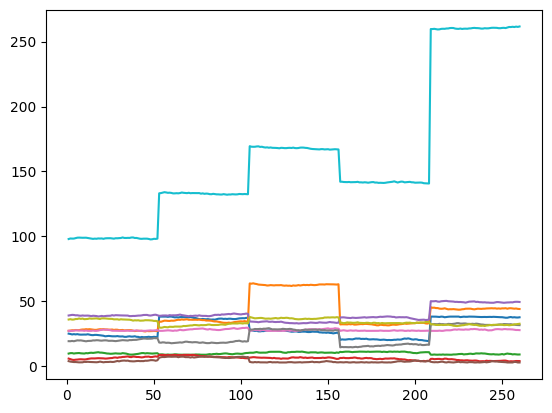

In [18]:
# Generation of data for prices
# 5 years with 52 realization/year (one/week)
# Why error divide by 0?
product_prices_over_time=np.zeros([10,52*5])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(barley,False)
  product_prices_over_time[0,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[0])+1),product_prices_over_time[0])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(chicken,False)
  product_prices_over_time[1,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[1])+1),product_prices_over_time[1])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(cow_d,False)
  product_prices_over_time[2,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[2])+1),product_prices_over_time[2])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(cow_s,False)
  product_prices_over_time[3,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[3])+1),product_prices_over_time[3])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(maize,False)
  product_prices_over_time[4,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[4])+1),product_prices_over_time[4])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(pig,False)
  product_prices_over_time[5,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[5])+1),product_prices_over_time[5])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(sorghum,False)
  product_prices_over_time[6,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[6])+1),product_prices_over_time[6])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(tomato,False)
  product_prices_over_time[7,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[7])+1),product_prices_over_time[7])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(triticale,False)
  product_prices_over_time[8,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[8])+1),product_prices_over_time[8])
for j in [0,52,52*2,52*3,52*4]:
  d=one_year(wheat,False)
  product_prices_over_time[9,j:j+52]=d
plt.plot(np.arange(1,len(product_prices_over_time[9])+1),product_prices_over_time[9])
filename = "wheat_price.csv"
np.savetxt(filename, product_prices_over_time, delimiter=",")

In [19]:
# Data generation of availability
# One realization for each year
product_availability_over_time=np.zeros([10,5])#
row=0
for i in products_a:
  for j in range(5):
    product_availability_over_time[row,j] = samples(i)
  row+=1
#product_availability_over_time

array([[8.19888213e+03, 7.51462986e+03, 8.52882187e+03, 8.34023963e+03,
        7.74409202e+03],
       [4.34691541e+04, 4.33728360e+04, 4.38042735e+04, 4.37897754e+04,
        4.30108850e+04],
       [2.27464001e+06, 2.23232243e+06, 2.20849885e+06, 2.21564568e+06,
        2.20839769e+06],
       [3.29469368e+06, 3.83147086e+06, 2.96352902e+06, 3.58102880e+06,
        3.70715596e+06],
       [1.51188168e+05, 1.73036906e+05, 1.80206061e+05, 1.61193554e+05,
        1.74666127e+05],
       [2.30904966e+06, 2.35502733e+06, 2.32103623e+06, 2.38652456e+06,
        2.34576806e+06],
       [1.19248655e+03, 1.13888932e+03, 1.14234748e+03, 1.18546300e+03,
        1.11457411e+03],
       [5.89963036e+03, 5.34745324e+03, 5.10548910e+03, 5.34316662e+03,
        6.18593517e+03],
       [1.19628806e+04, 1.13256262e+04, 1.09962232e+04, 1.24635606e+04,
        1.08617225e+04],
       [2.34905706e+04, 2.01408288e+04, 1.85372458e+04, 1.73201516e+04,
        1.82738129e+04]])

In [21]:
# Design of uncertainty set
# Budgeted set
# Normal distribution theorem to compute Gamma? No
# If data, have to scale them between [-1,1]? Yes

#Rs is a matrix containing n rows and 5*m columns
VaRProb = 0.95
VaReps = 1-VaRProb
mu_price=np.mean(product_prices_over_time, axis=1)
tmp = product_prices_over_time - mu_price.reshape(-1,1)@np.ones((1,5*52))
tmp_max = abs(tmp).max(1)
Zs_price = np.diag(1/tmp_max)@tmp
P_price = np.diag(tmp_max)

#Define Gamma_price
# Calibrating the budgeted set
tmp=np.sort(np.linalg.norm(Zs_price,1,axis=0))
Gamma_price=tmp[int(np.ceil((1-VaReps)*len(tmp)))-1]
print('Calibrating the budgeted set: Gamma={0:0.6f}'.format(Gamma_price))


#Defne Gamma_Availability
mu_avail=np.mean(product_availability_over_time, axis=1)
tmp = product_availability_over_time - mu_avail.reshape(-1,1)@np.ones((1,5))
tmp_max = abs(tmp).max(1)
Zs_avail = np.diag(1/tmp_max)@tmp
P_avail = np.diag(tmp_max)



#Define Gamma_availability
# Calibrating the budgeted set
tmp=np.sort(np.linalg.norm(Zs_avail,1,axis=0))
Gamma_availability=tmp[int(np.ceil((1-VaReps)*len(tmp)))-1]
print('Calibrating the budgeted set: Gamma={0:0.6f}'.format(Gamma_availability))

#Define Gamma_BMP

Calibrating the budgeted set: Gamma=6.230822
Calibrating the budgeted set: Gamma=6.375730


In [84]:
# Check constraint formulation for availability peaking one realization from Zs
deterministic_mean_avail = [arr[0] for arr in products_a]
sellersizes = []
for i in range(n):
    column_a = A[:,i]/deterministic_mean_avail[i]
    sellersizes.append(column_a)
    print(column_a.sum())
sellersizes = np.stack(sellersizes)
#print(sellersize[0])
#print(A[:,0])
Z = [arr[0] for arr in Zs_avail]
#print((mu_avail+P_avail@Z))
Anew = sellersizes.T*(mu_avail+P_avail@Z)
print(Anew)

# Check constraint formulation for prices peaking one realization from Zs
item_presence = np.where(A != 0, 1, 0)
Z = [arr[0] for arr in Zs_price]
Cpnew = item_presence*(mu_price+P_price@Z)
print(Cpnew[0])
print(Cp[0])

1.0
0.9999999999999999
0.7538645061278088
0.9684394757318321
0.8732150200112607
1.0
1.0
1.0
1.0
1.0
[[0.00000000e+00 0.00000000e+00 1.91786173e+05 0.00000000e+00
  1.12789278e+04 3.58415962e+05 2.97494466e+01 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [4.37028100e+02 1.11167868e+04 0.00000000e+00 5.79639753e+05
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [4.25607513e+02 0.00000000e+00 0.00000000e+00 1.68519081e+05
  3.18572281e+04 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  3.14990362e+04 9.95793164e+05 2.16489575e+02 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [3.44578828e+02 0.00000000e+00 2.52163046e+05 5.74250067e+05
  9.39206301e+03 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.60933632e+02 0.00000000e+00]
 [1.42445919e+03 1.25778536e+04 5.16496136e+04 2.73211289e+05
  0.00000000e+00 7.09023064e+04 1.43035396e+02 0.0000

In [111]:
#Solve the robustified problem

# Find indices correspondent to a certain cluster to apply 'regulating authority constraints'
table1A = np.isin(itemtype,['S','B'])
table1B = np.isin(itemtype,['P'])
slurries = np.isin(itemtype,['S'])
secondharvest = np.isin(itemtype,['P2'])

#Extract value from 'bmp_curve' at the given HRT
HRT=50
HRTminus1 = 1/HRT
BMP = []
for i in range(len(data['Item characteristics'].values[:,0])):
    BMPsubstrate = bmp_curve[i][HRT-1]
    BMP.append(BMPsubstrate)

#Create model
model=ro.Model('Biomethane supply-chain robust')

#Define variables
s = model.dvar(1)
x = model.dvar((n,m))          #
z = model.rvar(n) #Random variables = perturbation to availabilities
#w = model.rvar(n) #Random variables = perturbation to prices
#l = model.rvar(n) #Random variables = perturbation to BMP

#Define 'availability uncertainty set'
availabilitySet = (-1<=z, z<=1, rso.norm(z,1)<=Gamma_availability)
#Define 'prices uncertainty set'
#pricesSet = (-1<=w, w<=1, rso.norm(w,1)<=Gamma_price)
#Define 'BMP uncertainty set'

#List the objective and constraints
model.max(Nminus1*(p_ch4*(VS*BMP/1000)@x.sum(axis=1)-(Cp.T*x).sum()-(Ct.T*x).sum())) #How shall I reformulate the objective function?
#model.max(s)
#model.st((s <= Nminus1*(p_ch4*(VS*BMP/1000)@x.sum(axis=1)-((item_presence*(mu_price+P_price@w)).T*x).sum()-(Ct.T*x).sum())).forall(pricesSet))
# Rewrite J as constraint (keep 'max' in the actual J) > 2 alternatives: (i) forall.forall; (ii) two constriants for revenue and costs 
# How shall I reformulate the objective function? Can I have two sources of uncertainty in the J? Break down in two constraints? Or writing forall(Set1).forall(Set2)?
#Anew = sellersizes.T*(mu_avail+P_avail@z)
model.st((x <= (sellersizes.T*(mu_avail+P_avail@z)).T).forall(availabilitySet))       # Availability constraint 

for i in range(np.size(k,1)):
    model.st(k[:,i]@(x.sum(axis=1)) <= bnds[i][1]*x.sum()) # Technical constraint (max)
    model.st(k[:,i]@(x.sum(axis=1)) >= bnds[i][0]*x.sum()) # Technical constraint (min)
model.st(Vr*N == HRT*x.sum()) # HRT hard constraint 
model.st(x >= 0)

#Add constraint to consume substrate of 'myplant'...can't be equality constraint for each set??
#model.st((x.T[-1] == sellersizes.T*(mu_avail+P_avail@z)[-1]).forall(availabilitySet))

# Add constraints from regulating autorithy
model.st(x[table1A].sum() >= 0.7*x.sum())
model.st(x[table1B].sum() <= 0.3*x.sum())
model.st(x[secondharvest].sum() <= 0.2*x.sum())
model.st(x[slurries].sum() >= 0.4*x.sum())

#Solve the model
model.solve(my_solver)
opt_obj_robust = model.get()  #
opt_x_robust = x.get()

print('The net revenue for the purchase horizon of interest is', round(opt_obj_robust,2), 
      'euro/day and the optimal fluxes of items to be purchased are', np.round(opt_x_robust, decimals=2))

Being solved by Mosek...


Error: rescode.err_license_expired(1001): The license has expired.


In [107]:
# Just for checking purposes
x = opt_x_robust
HRT = Vr*N/x.sum()
print(f'HRT is {HRT}')
f_obj = p_ch4*(VS*BMP/1000)@x.sum(axis=1)/HRT
f_obj2 = (Cp.T*x).sum()/HRT
f_obj3 = (Ct.T*x).sum()/HRT
print(f_obj)
print(f_obj2)
print(f_obj3)
print(f_obj-f_obj2-f_obj3)


#diet
for i,name in zip(range(len(x)),data['Item characteristics'].values[:,0]):
    itempercentage = x[i].sum()/x.sum()*100
    print(f'{name} is {round(itempercentage,2)}% of the influent diet')
    

#
table1A = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S','B'])]).sum()
table1B = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P'])]).sum()
slurries = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['S'])]).sum()
secondharvest = np.array([s for f, s in zip(itemtype, x) if any(target in f for target in ['P2'])]).sum()
ciao = [table1A*100/x.sum() - 70, 30 - table1B*100/x.sum(), slurries*100/x.sum() - 40, 20 - secondharvest*100/x.sum()]
for i in range(len(ciao)):
    active = [ciao[i] if ciao[i]<0 else 0]
    print(f'Autorithy constraint {i} not respected by {round(active[0],2)}')

#
for i in range(np.size(k,1)):
    deltamax = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][1] # Technical constraint (max)
    deltamin = k[:,i]@(x.sum(axis=1))/x.sum() - bnds[i][0] # Technical constraint (min)
    print(f'Technical constriant {i} has margin to UB equal to {round(deltamax,2)}')
    print(f'Technical constriant {i} has margin to LB equal to {round(deltamin,2)}')
deltaHRTmax = Vr*N/x.sum() - bnds[7][1] # HRT constraint (max)
print(f'HRT constriant has margin to UB equal to {round(deltaHRTmax,2)}')
deltaHRTmin = Vr*N/x.sum() - bnds[7][0] # HRT constraint (min)
print(f'HRT constriant has margin to LB equal to {round(deltaHRTmin,2)}')

HRT is 50.0
34526.362600675224
11968.945192207224
2572.9856322032642
19984.431776264733
Barley silage is 5.2% of the influent diet
Chicken dung is 0.0% of the influent diet
Cow dung is 0.0% of the influent diet
Cow slurry is 74.8% of the influent diet
Maize silage is 20.0% of the influent diet
Pig slurry is 0.0% of the influent diet
Sorghum silage is 0.0% of the influent diet
Tomato peels is 0.0% of the influent diet
Triticale silage is 0.0% of the influent diet
Wheat byproducts is 0.0% of the influent diet
Autorithy constraint 0 not respected by 0
Autorithy constraint 1 not respected by 0
Autorithy constraint 2 not respected by 0
Autorithy constraint 3 not respected by 0
Technical constriant 0 has margin to UB equal to 0.0
Technical constriant 0 has margin to LB equal to 120.0
Technical constriant 1 has margin to UB equal to -0.22
Technical constriant 1 has margin to LB equal to 3.58
Technical constriant 2 has margin to UB equal to -13.64
Technical constriant 2 has margin to LB equal 